# Labwork 6 -- Map by GPU
Le Nghiem Thanh Thuy - 2540023

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


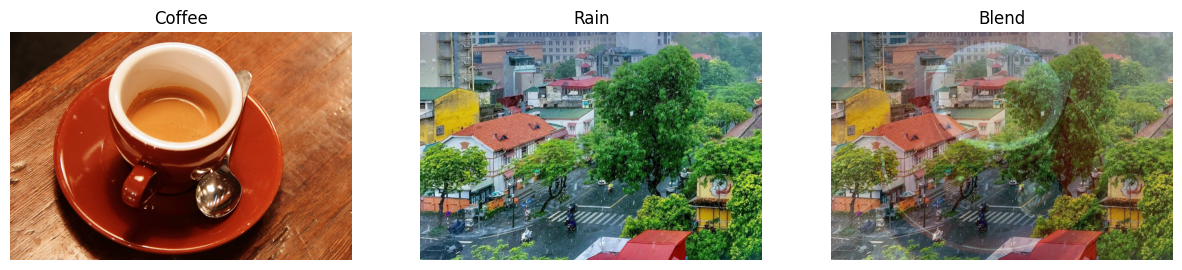

In [17]:
from google.colab import drive
drive.mount('/content/drive')

from skimage import data
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Coffee
coffee = data.coffee()

# Rain
rain_path = "/content/drive/MyDrive/rain.jpg"
rain = np.array(Image.open(rain_path).convert("RGB"))

# Resize về đúng kích thước coffee
rain = np.array(Image.fromarray(rain).resize((600, 400)))

# Blend
alpha = 0.3

blend = (
    alpha * coffee.astype(float)
    + (1 - alpha) * rain.astype(float)
)

blend = np.clip(blend, 0, 255).astype(np.uint8)

# Hiển thị
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(coffee)
plt.title("Coffee")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(rain)
plt.title("Rain")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blend)
plt.title("Blend")
plt.axis("off")

plt.show()

In [2]:
import time
import numba
from numba import cuda

print("CUDA available:", cuda.is_available())

CUDA available: True


## 1. Binarization

In [23]:
@cuda.jit
def grayscale2D(src, dst, argv):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x  # column
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y  # row

    #dst[tidy, tidx, 0] = 0 if src[tidy, tidx, 0] < argv else 100
    #dst[tidy, tidx, 1] = 0 if src[tidy, tidx, 1] < argv else 100
    #dst[tidy, tidx, 2] = 0 if src[tidy, tidx, 2] < argv else 100
    gray = (src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) // 3

    # Thresholding
    if gray < argv:
        dst[tidy, tidx] = 0
    else:
        dst[tidy, tidx] = 1

In [30]:
height, width, channels = coffee.shape

devSrc = cuda.to_device(coffee)
#devDst = cuda.device_array((height, width, channels), np.uint8)
devDst = cuda.device_array((height, width), np.uint8)

blockSize2D = (16, 16)
gridSize2D = ((width + blockSize2D[0] - 1) // blockSize2D[0],
              (height + blockSize2D[1] - 1) // blockSize2D[1])

start = time.time()
grayscale2D[gridSize2D, blockSize2D](devSrc, devDst, 100)
cuda.synchronize()
gpuTime = time.time() - start

coffee_grayscale = devDst.copy_to_host()

print(f"GPU time: {gpuTime * 1000:.2f} ms")

GPU time: 145.47 ms


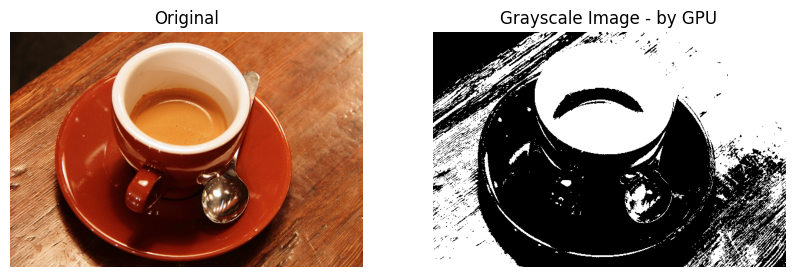

In [32]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(coffee)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Grayscale Image - by GPU")
#plt.imshow(coffee_grayscale)
plt.imshow(coffee_grayscale, cmap='gray', vmin=0, vmax=1)
plt.axis("off")
plt.show()

## 2. Brightness Control

In [39]:
@cuda.jit
def bright2D(src, dst, argv):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if tidy < src.shape[0] and tidx < src.shape[1]:

        val_r = src[tidy, tidx, 0] + argv
        if val_r > 255:
            val_r = 255
        elif val_r < 0:
            val_r = 0
        dst[tidy, tidx, 0] = val_r

        val_g = src[tidy, tidx, 1] + argv
        if val_g > 255:
            val_g = 255
        elif val_g < 0:
            val_g = 0
        dst[tidy, tidx, 1] = val_g

        val_b = src[tidy, tidx, 2] + argv
        if val_b > 255:
            val_b = 255
        elif val_b < 0:
            val_b = 0
        dst[tidy, tidx, 2] = val_b

In [42]:
height, width, channels = coffee.shape
devSrc = cuda.to_device(coffee)

devDst = cuda.device_array((height, width, channels), np.uint8)

blockSize2D = (16, 16)
gridSize2D = ((width + blockSize2D[0] - 1) // blockSize2D[0],
              (height + blockSize2D[1] - 1) // blockSize2D[1])

start = time.time()
bright2D[gridSize2D, blockSize2D](devSrc, devDst, 80)
cuda.synchronize()
gpuTime = time.time() - start
brightness_img = devDst.copy_to_host()

print(f"GPU time: {gpuTime * 1000:.2f} ms")

GPU time: 0.62 ms


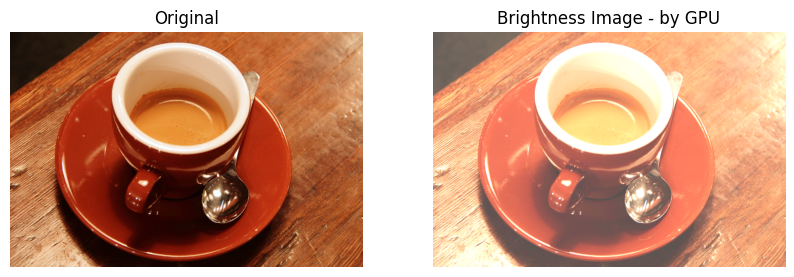

In [43]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(coffee)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Brightness Image - by GPU")
plt.imshow(brightness_img)
plt.axis("off")
plt.show()

## 3. Blending images

In [44]:
@cuda.jit
def blend2D(src1, src2, dst, alpha):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x  # column
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y  # row

    for c in range(3):
        dst[tidy, tidx, c] = src1[tidy, tidx, c] * alpha + src2[tidy, tidx, c] * (1 - alpha)

        if dst[tidy, tidx, c] < 0:
            dst[tidy, tidx, c] = 0
        elif dst[tidy, tidx, c] > 255:
            dst[tidy, tidx, c] = 255



In [48]:
height, width, channels = coffee.shape

devSrc1 = cuda.to_device(coffee)
devSrc1 = cuda.to_device(rain)
devDst = cuda.device_array((height, width, channels), np.uint8)

blockSize2D = (16, 16)
gridSize2D = ((width + blockSize2D[0] - 1) // blockSize2D[0],
              (height + blockSize2D[1] - 1) // blockSize2D[1])

start = time.time()
blend2D[gridSize2D, blockSize2D](devSrc, devSrc1, devDst, 0.3)
cuda.synchronize()
gpuTime = time.time() - start

blend_img = devDst.copy_to_host()

print(f"GPU time: {gpuTime * 1000:.2f} ms")

GPU time: 124.80 ms


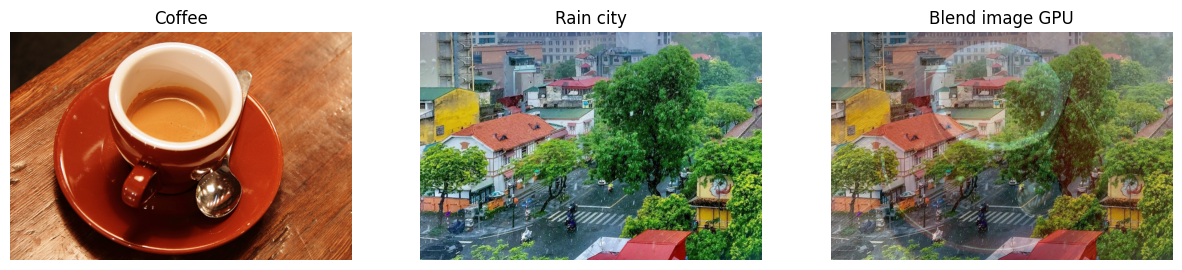

In [50]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("Coffee")
plt.imshow(coffee)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Rain city")
plt.imshow(rain)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Blend image GPU")
plt.imshow(blend_img)
plt.axis("off")

plt.show()